# Clustering -  ESCNNA

1. Preparación de datos: variables numéricas se deben normalizar y variables categóricas se crean dummies
2. Aprendizaje del Modelo: Kmeans, método del codo
3. Evaluación del Modelo: Inertia, silueta
4. Perfilamiento: Descripción de centroides



In [73]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica



# 1. Preparación de Datos

* Previa limpieza de atípicos, nulos y altas correlaciones









In [74]:
# Se cargan los datos
df = pd.read_excel("dataset_final.xlsx",sheet_name="Data") #Cargar datos en excel
df.head() #muestras los 5 primeros registros

,DEPARTAMENTO,ARTICULO,CIRCUNSTACIA_DE_LA_CAPTURA,GENERO,Riesgo_Departamento,Momento_Delito,Tipo_Victima,Tipo_Delito,Entorno,Reincidencia
0,SANTANDER,ARTÍCULO 209,FLAGRANCIA LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No
1,VALLE DEL CAUCA,ARTÍCULO 208,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Madrugada,Adolescente,Pornografia,Rural_Concentrado,No
2,VALLE DEL CAUCA,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Noche,Niña,Acceso_Carnal,Urbano_Central,No
3,ATLÁNTICO,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No
4,CUNDINAMARCA,ARTÍCULO 211,ORDEN JUDICIAL LEY 906,MASCULINO,Alto,Dia,Adolescente,Explotacion,Rural_Disperso,No


In [75]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   DEPARTAMENTO                631 non-null    object
 1   ARTICULO                    631 non-null    object
 2   CIRCUNSTACIA_DE_LA_CAPTURA  631 non-null    object
 3   GENERO                      631 non-null    object
 4   Riesgo_Departamento         631 non-null    object
 5   Momento_Delito              631 non-null    object
 6   Tipo_Victima                631 non-null    object
 7   Tipo_Delito                 631 non-null    object
 8   Entorno                     631 non-null    object
 9   Reincidencia                631 non-null    object
dtypes: object(10)
memory usage: 49.4+ KB


In [76]:
#Se ajustan el tipo de dato de object a Category
df['DEPARTAMENTO']=df['DEPARTAMENTO'].astype('category')
df['ARTICULO']=df['ARTICULO'].astype('category')
df['CIRCUNSTACIA_DE_LA_CAPTURA']=df['CIRCUNSTACIA_DE_LA_CAPTURA'].astype('category')
df['GENERO']=df['GENERO'].astype('category')
df['Riesgo_Departamento']=df['Riesgo_Departamento'].astype('category')
df['Momento_Delito']=df['Momento_Delito'].astype('category')
df['Tipo_Victima']=df['Tipo_Victima'].astype('category')
df['Tipo_Delito']=df['Tipo_Delito'].astype('category')
df['Entorno']=df['Entorno'].astype('category')
df['Reincidencia']=df['Reincidencia'].astype('category')





In [77]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   DEPARTAMENTO                631 non-null    category
 1   ARTICULO                    631 non-null    category
 2   CIRCUNSTACIA_DE_LA_CAPTURA  631 non-null    category
 3   GENERO                      631 non-null    category
 4   Riesgo_Departamento         631 non-null    category
 5   Momento_Delito              631 non-null    category
 6   Tipo_Victima                631 non-null    category
 7   Tipo_Delito                 631 non-null    category
 8   Entorno                     631 non-null    category
 9   Reincidencia                631 non-null    category
dtypes: category(10)
memory usage: 8.2 KB


In [78]:
df.describe()

,DEPARTAMENTO,ARTICULO,CIRCUNSTACIA_DE_LA_CAPTURA,GENERO,Riesgo_Departamento,Momento_Delito,Tipo_Victima,Tipo_Delito,Entorno,Reincidencia
count,631,631,631,631,631,631,631,631,631,631
unique,9,9,3,2,3,3,3,4,4,2
top,CUNDINAMARCA,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Bajo,Noche,Adolescente,Abuso,Rural_Concentrado,No
freq,175,304,480,617,234,242,216,162,181,534


<Axes: xlabel='ARTICULO'>

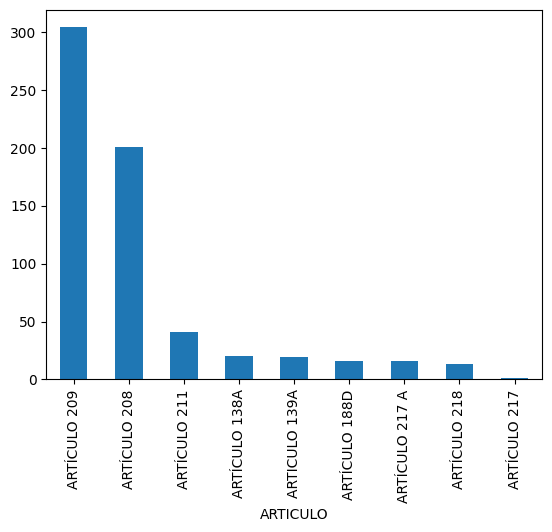

In [79]:
df['ARTICULO'].value_counts().plot(kind='bar')

<Axes: xlabel='CIRCUNSTACIA_DE_LA_CAPTURA'>

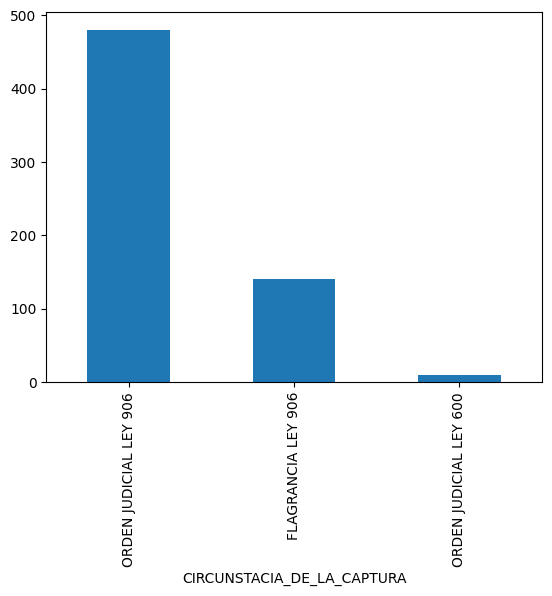

In [80]:
df['CIRCUNSTACIA_DE_LA_CAPTURA'].value_counts().plot(kind='bar')

<Axes: xlabel='Tipo_Victima'>

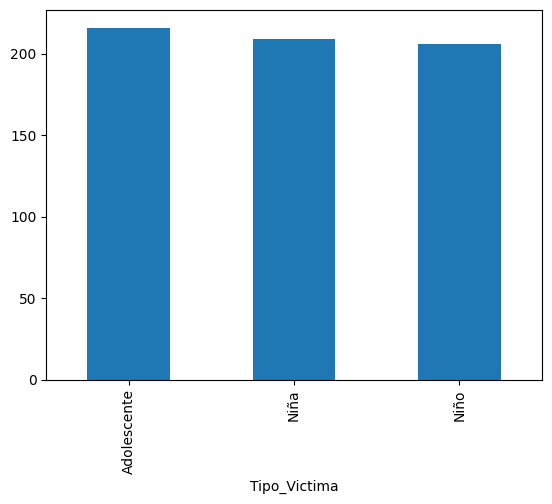

In [81]:
df['Tipo_Victima'].value_counts().plot(kind='bar')

<Axes: xlabel='Entorno'>

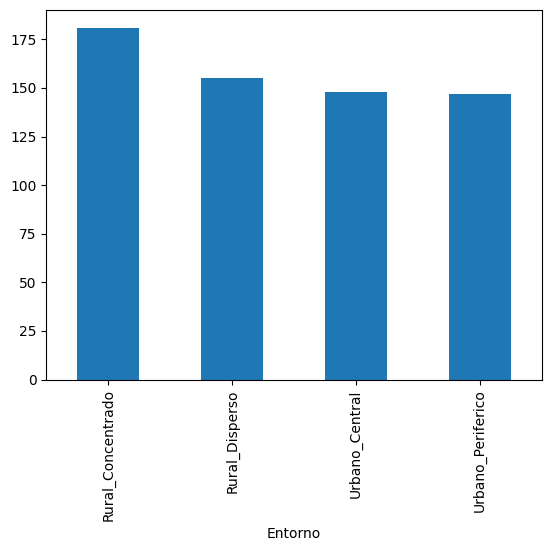

In [82]:
df['Entorno'].value_counts().plot(kind='bar')


<Axes: xlabel='Tipo_Delito'>

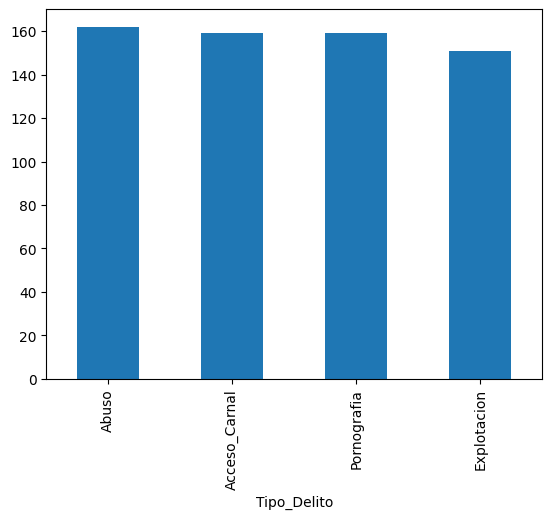

In [83]:
df['Tipo_Delito'].value_counts().plot(kind='bar')

In [ ]:
!pip install ydata-profiling

In [85]:
from ydata_profiling import ProfileReport

profile_data=ProfileReport(df, minimal=True) # minimal=False
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 181.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [86]:
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

* Transformaciones: normalizar y crear dummies

In [87]:
#Copia de los datos
data=df.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   DEPARTAMENTO                631 non-null    category
 1   ARTICULO                    631 non-null    category
 2   CIRCUNSTACIA_DE_LA_CAPTURA  631 non-null    category
 3   GENERO                      631 non-null    category
 4   Riesgo_Departamento         631 non-null    category
 5   Momento_Delito              631 non-null    category
 6   Tipo_Victima                631 non-null    category
 7   Tipo_Delito                 631 non-null    category
 8   Entorno                     631 non-null    category
 9   Reincidencia                631 non-null    category
dtypes: category(10)
memory usage: 8.2 KB


In [88]:
data = pd.get_dummies(data, columns=['GENERO', 'Reincidencia'], drop_first=True, dtype=int)
data.head()

,DEPARTAMENTO,ARTICULO,CIRCUNSTACIA_DE_LA_CAPTURA,Riesgo_Departamento,Momento_Delito,Tipo_Victima,Tipo_Delito,Entorno,GENERO_MASCULINO,Reincidencia_Si
0,SANTANDER,ARTÍCULO 209,FLAGRANCIA LEY 906,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,1,0
1,VALLE DEL CAUCA,ARTÍCULO 208,ORDEN JUDICIAL LEY 906,Medio,Madrugada,Adolescente,Pornografia,Rural_Concentrado,1,0
2,VALLE DEL CAUCA,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,Medio,Noche,Niña,Acceso_Carnal,Urbano_Central,1,0
3,ATLÁNTICO,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,1,0
4,CUNDINAMARCA,ARTÍCULO 211,ORDEN JUDICIAL LEY 906,Alto,Dia,Adolescente,Explotacion,Rural_Disperso,1,0


In [89]:
data.describe()

,GENERO_MASCULINO,Reincidencia_Si
count,631.000000,631.000000
mean,0.977813,0.153724
std,0.147408,0.360970
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,0.000000
max,1.000000,1.000000


In [90]:
data = pd.get_dummies(data, columns=['DEPARTAMENTO','ARTICULO','CIRCUNSTACIA_DE_LA_CAPTURA','Riesgo_Departamento','Momento_Delito','Tipo_Victima', 'Tipo_Delito','Entorno'], drop_first=False, dtype=int)
data.head()

,GENERO_MASCULINO,Reincidencia_Si,DEPARTAMENTO_ANTIOQUIA,DEPARTAMENTO_ATLÁNTICO,DEPARTAMENTO_CUNDINAMARCA,DEPARTAMENTO_HUILA,DEPARTAMENTO_MAGDALENA,DEPARTAMENTO_META,DEPARTAMENTO_SANTANDER,DEPARTAMENTO_TOLIMA,...,Tipo_Victima_Niña,Tipo_Victima_Niño,Tipo_Delito_Abuso,Tipo_Delito_Acceso_Carnal,Tipo_Delito_Explotacion,Tipo_Delito_Pornografia,Entorno_Rural_Concentrado,Entorno_Rural_Disperso,Entorno_Urbano_Central,Entorno_Urbano_Periferico
0,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
3,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


# 2. Aprendizaje del Modelo
* Metodo del codo
* Aplicar kmeans

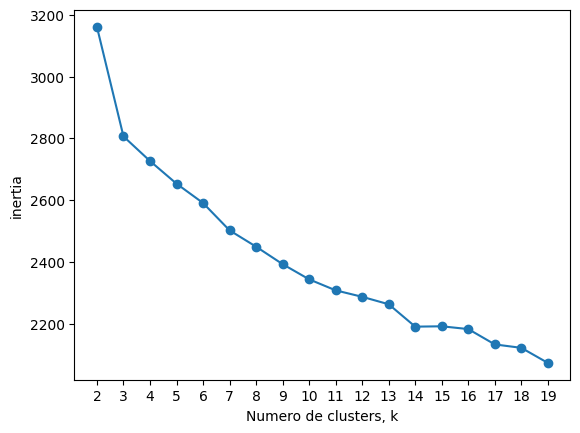

In [91]:
from sklearn.cluster import KMeans

ks = range(2, 20) # crear valores del 2 al 20
inertias = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=1300)
    model.fit(data)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

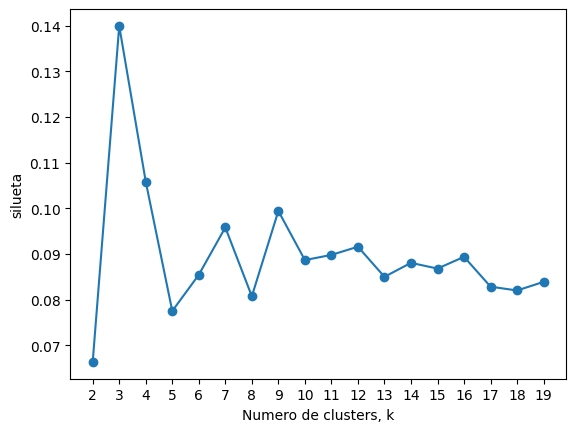

In [92]:
#Método de la rodilla: silueta
from sklearn import metrics

ks = range(2, 20) # crear valores del 2 al 20
siluetas = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300)
    model.fit(data)
    sil=metrics.silhouette_score(data, model.labels_)
    siluetas.append(sil)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, siluetas, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('silueta')
plt.xticks(ks)
plt.show()

In [93]:
#Creación de modelo de clustering con Kmeans
from sklearn.cluster import KMeans
k=3
model = KMeans(n_clusters=k, max_iter=300, n_init=15, random_state=42)
model.fit(data) #100% datos

KMeans(n_clusters=3, n_init=15, random_state=42)

# 3. Evaluación del Modelo


*   Inertia: valor pequeño esperado
*   Silueta: valor positivo esperado, idealmente mayor a 0.5



In [94]:
#Evaluación
from sklearn import metrics

#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil=metrics.silhouette_score(data, model.labels_)
print('Silueta:',sil)

Inercia o cohesión: 2806.0920080520054
Silueta: 0.13994005824843897


# 4. Perfilamiento

Descripción de centroides

In [95]:
#Centroides almacenados dentro del modelo
model.cluster_centers_

array([[ 9.78632479e-01,  1.41025641e-01, -3.05311332e-16,
         1.58119658e-01,  4.99600361e-16,  1.45299145e-01,
         1.45299145e-01,  1.79487179e-01,  2.17948718e-01,
         1.53846154e-01, -2.91433544e-16,  8.54700855e-03,
         1.28205128e-02,  2.56410256e-02,  3.97435897e-01,
         5.04273504e-01,  3.41880342e-02, -6.07153217e-18,
         4.27350427e-03,  1.28205128e-02,  2.35042735e-01,
         1.70940171e-02,  7.47863248e-01,  4.99600361e-16,
         1.00000000e+00, -5.55111512e-17,  3.76068376e-01,
         2.64957265e-01,  3.58974359e-01,  3.58974359e-01,
         3.37606838e-01,  3.03418803e-01,  2.43589744e-01,
         2.69230769e-01,  2.73504274e-01,  2.13675214e-01,
         2.99145299e-01,  2.26495726e-01,  2.43589744e-01,
         2.30769231e-01],
       [ 9.81981982e-01,  1.62162162e-01,  6.80180180e-01,
        -9.71445147e-17,  6.66133815e-16, -1.31838984e-16,
        -1.31838984e-16,  9.71445147e-17,  2.77555756e-17,
        -1.17961196e-16,  3.19

In [99]:
#Centroides de los cluster se convierten  en un dataframe de pandas
centroides=pd.DataFrame(model.cluster_centers_, columns=data.columns.values)
centroides.round(1)

,GENERO_MASCULINO,Reincidencia_Si,DEPARTAMENTO_ANTIOQUIA,DEPARTAMENTO_ATLÁNTICO,DEPARTAMENTO_CUNDINAMARCA,DEPARTAMENTO_HUILA,DEPARTAMENTO_MAGDALENA,DEPARTAMENTO_META,DEPARTAMENTO_SANTANDER,DEPARTAMENTO_TOLIMA,...,Tipo_Victima_Niña,Tipo_Victima_Niño,Tipo_Delito_Abuso,Tipo_Delito_Acceso_Carnal,Tipo_Delito_Explotacion,Tipo_Delito_Pornografia,Entorno_Rural_Concentrado,Entorno_Rural_Disperso,Entorno_Urbano_Central,Entorno_Urbano_Periferico
0,1.0,0.1,-0.0,0.2,0.0,0.1,0.1,0.2,0.2,0.2,...,0.3,0.3,0.2,0.3,0.3,0.2,0.3,0.2,0.2,0.2
1,1.0,0.2,0.7,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,...,0.3,0.3,0.3,0.3,0.2,0.3,0.3,0.3,0.2,0.2
2,1.0,0.2,-0.0,-0.0,1.0,-0.0,-0.0,0.0,0.0,-0.0,...,0.3,0.4,0.3,0.2,0.2,0.3,0.3,0.3,0.2,0.3


##PERFILAMIENTO DE LOS 3 CLUSTER

In [100]:

# Extraemos los centroides del modelo estabilizado
centroides = pd.DataFrame(model.cluster_centers_, columns=data.columns.values)

# Imprimimos los perfiles
for i in range(len(centroides)):
    print(f"--- PERFIL CLÚSTER {i} ---")
    top_caracteristicas = centroides.iloc[i].sort_values(ascending=False).head(5)
    for caracteristica, valor in top_caracteristicas.items():
        print(f"  * {caracteristica}: {valor:.2f} ({(valor*100):.1f}%)")
    print("\n")

--- PERFIL CLÚSTER 0 ---
  * Riesgo_Departamento_Bajo: 1.00 (100.0%)
  * GENERO_MASCULINO: 0.98 (97.9%)
  * CIRCUNSTACIA_DE_LA_CAPTURA_ORDEN JUDICIAL LEY 906: 0.75 (74.8%)
  * ARTICULO_ARTÍCULO 209: 0.50 (50.4%)
  * ARTICULO_ARTÍCULO 208: 0.40 (39.7%)


--- PERFIL CLÚSTER 1 ---
  * Riesgo_Departamento_Medio: 1.00 (100.0%)
  * GENERO_MASCULINO: 0.98 (98.2%)
  * CIRCUNSTACIA_DE_LA_CAPTURA_ORDEN JUDICIAL LEY 906: 0.71 (71.2%)
  * DEPARTAMENTO_ANTIOQUIA: 0.68 (68.0%)
  * ARTICULO_ARTÍCULO 209: 0.46 (45.9%)


--- PERFIL CLÚSTER 2 ---
  * DEPARTAMENTO_CUNDINAMARCA: 1.00 (100.0%)
  * Riesgo_Departamento_Alto: 1.00 (100.0%)
  * GENERO_MASCULINO: 0.97 (97.1%)
  * CIRCUNSTACIA_DE_LA_CAPTURA_ORDEN JUDICIAL LEY 906: 0.84 (84.0%)
  * ARTICULO_ARTÍCULO 209: 0.48 (48.0%)




**DESCRIPCIÓN DE PERFILES**

1. Clúster 0: "Perfil de Riesgo Bajo (Dispersión Nacional)"
Este grupo agrupa los incidentes ocurridos en departamentos catalogados con un nivel de riesgo bajo (el 100% de los casos de este grupo comparten esta etiqueta).

Dinámica Judicial: El 74.8% de las capturas se logran mediante orden judicial.

Delitos: Es el grupo donde el Artículo 208 (Acceso carnal abusivo, 39.7%) tiene una presencia más fuerte en comparación con los otros clústeres, casi empatando con el Artículo 209 (50.4%).

Conclusión: Representa la criminalidad en zonas de menor densidad o alerta, donde el abuso (Art. 208 y 209) requiere un esfuerzo investigativo estándar para lograr la captura del agresor masculino.


2. Clúster 1: "Perfil de Riesgo Medio - Foco Antioquia"
Este es el grupo más importante para tu proyecto, ya que abarca el entorno de Medellín y el departamento de Antioquia. El algoritmo aisló matemáticamente a los departamentos de riesgo medio (100%), pero encontró que Antioquia domina absolutamente este escenario, representando el 68% de todos los casos del clúster.

Dinámica Judicial: Curiosamente, tiene la tasa más "baja" de captura por orden judicial (71.2%) comparado con los otros grupos. Esto podría sugerir una leve, pero mayor, proporción de capturas en flagrancia en esta región, posiblemente por la dinámica urbana de ciudades como Medellín o controles policiales más activos.

Conclusión: Un arquetipo territorial específico. Define a Antioquia como el epicentro del riesgo medio a nivel nacional en temas de ESCNNA y abuso de menores.

3. Clúster 2: "Perfil de Riesgo Alto - Foco Cundinamarca"
El algoritmo detectó un patrón tan extremo en Cundinamarca que decidió crear un clúster exclusivo para este departamento. El 100% de los casos aquí ocurren en Cundinamarca y el 100% están etiquetados como Riesgo Alto.

Dinámica Judicial: Tiene la tasa más alta de capturas por Orden Judicial (84.0%).

Conclusión: Este es el perfil de máxima complejidad investigativa. El altísimo porcentaje de órdenes judiciales (84%) sugiere que en Cundinamarca los agresores operan de formas más estructuradas, ocultas o sistemáticas, requiriendo investigaciones judiciales mucho más profundas y prolongadas para lograr emitir la orden de captura, haciendo casi imposible atraparlos en flagrancia.




In [101]:
#En el dataframe original, se adiciona el cluster asignado a cada registro
df['cluster']=model.labels_
df.head()

,DEPARTAMENTO,ARTICULO,CIRCUNSTACIA_DE_LA_CAPTURA,GENERO,Riesgo_Departamento,Momento_Delito,Tipo_Victima,Tipo_Delito,Entorno,Reincidencia,cluster
0,SANTANDER,ARTÍCULO 209,FLAGRANCIA LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No,0
1,VALLE DEL CAUCA,ARTÍCULO 208,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Madrugada,Adolescente,Pornografia,Rural_Concentrado,No,1
2,VALLE DEL CAUCA,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Noche,Niña,Acceso_Carnal,Urbano_Central,No,1
3,ATLÁNTICO,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No,0
4,CUNDINAMARCA,ARTÍCULO 211,ORDEN JUDICIAL LEY 906,MASCULINO,Alto,Dia,Adolescente,Explotacion,Rural_Disperso,No,2


<Axes: ylabel='count'>

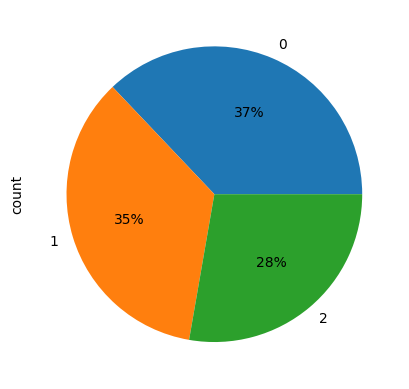

In [102]:
#Cantidad de datos en cada cluster
df["cluster"].value_counts().plot(kind='pie',autopct='%.0f%%')